Successfully loaded dataset with 30 rows.

--- Correlation Matrix ---
                 Unnamed: 0  YearsExperience    Salary
Unnamed: 0         1.000000         0.986460  0.960826
YearsExperience    0.986460         1.000000  0.978242
Salary             0.960826         0.978242  1.000000

--- Model Performance ---
Intercept (c): 24380.20
Coefficient (m): 9423.82
Mean Squared Error: 49830096.86
R-squared Score: 0.90


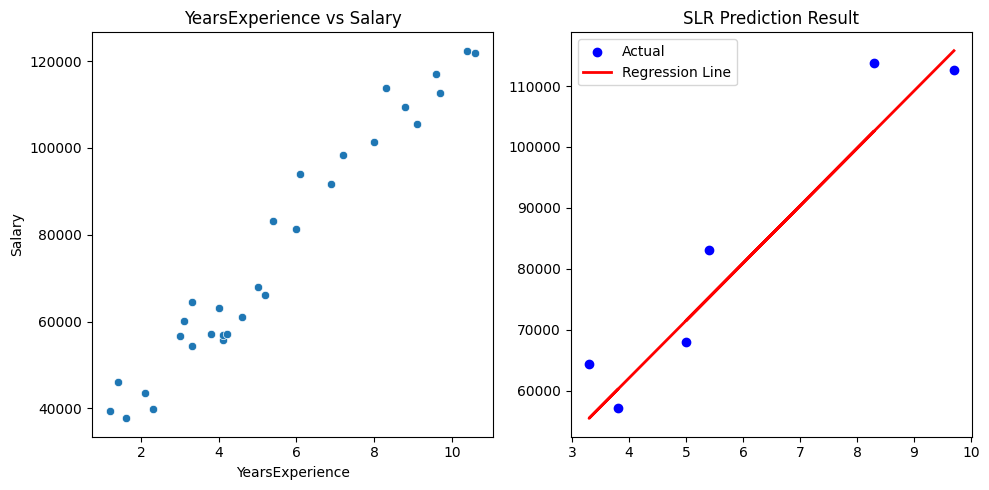

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. SETUP DATA (LOADING YOUR DATASET)
# Replace 'your_data.csv' with your actual filename

df = pd.read_csv('Salary_Dataset.csv')
    
# UPDATE THESE: Replace with the exact column names from your CSV
FEATURE_COL = 'YearsExperience' 
TARGET_COL = 'Salary'
print(f"Successfully loaded dataset with {len(df)} rows.")


# 2. FEATURE SELECTION & VISUALIZATION
print("\n--- Correlation Matrix ---")
print(df.corr())

plt.figure(figsize=(10, 5))

# Plot 1: Scatter plot
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x=FEATURE_COL, y=TARGET_COL)
plt.title(f'{FEATURE_COL} vs {TARGET_COL}')

# 3. PREPARE DATA FOR MODELING
X_data = df[[FEATURE_COL]] 
y_data = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# 4. IMPLEMENT SIMPLE LINEAR REGRESSION
model = LinearRegression()
model.fit(X_train, y_train)

# 5. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 6. EVALUATE
print("\n--- Model Performance ---")
print(f"Intercept (c): {model.intercept_:.2f}")
print(f"Coefficient (m): {model.coef_[0]:.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")

# Plot 2: Regression Line
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('SLR Prediction Result')
plt.legend()

plt.tight_layout()
plt.show()